# Per-Stimulus Noise Calibration Demo

This notebook demonstrates the current color-cue psychophysics paradigm. We keep the 2AFC task, but the goal is now subject-specific noise calibration.

The workflow is:

1. Measure a baseline 2AFC psychometric curve with no injected external theta noise.
2. Fit a Gaussian 2AFC psychometric model.
3. Interpret the fitted `sigma_stimulus` as the subject's per-stimulus internal noise, `sigma_internal`.
4. Choose experimenter-defined total per-stimulus noise levels, `sigma_target`.
5. Compute subject-specific external noise with `sigma_ext = sqrt(sigma_target^2 - sigma_internal^2)`.
6. Verify that subjects with different baseline thresholds produce overlapping psychometric curves once total noise is matched.


In [17]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from color_cue.psychophysics import (
    fit_all_gaussian_psychometrics,
    gaussian_psychometric,
    make_noise_calibration_table,
    make_trial_table,
    plot_matched_noise_psychometrics,
    simulate_matched_noise_observers,
    simulate_observer,
    summarize_choices,
)

THETA0 = -np.pi / 4
DELTA_THETAS = (-0.24, -0.16, -0.08, -0.04, 0.04, 0.08, 0.16, 0.24)
CONTEXTS = ("redder",)
N_REPEATS = 160
RNG = np.random.default_rng(11)


## Simulate Two Subjects With Different Baseline Thresholds

For this sandbox demo, we create two latent-theta observers. In a real experiment, the internal noise values would be unknown and estimated from the baseline psychometric curve.

In [18]:
true_subjects = pd.DataFrame(
    {
        "subject_id": ["precise", "noisy"],
        "sigma_internal_true": [0.04, 0.09],
    }
)
true_subjects


,subject_id,sigma_internal_true
0,precise,0.04
1,noisy,0.09


## Experiment 1: Baseline Psychometric Calibration

The baseline task uses `sigma_ext = 0`. The Gaussian 2AFC fit returns a per-stimulus total noise estimate. In this baseline condition, that value is interpreted as `sigma_internal`.

The comparison variable has a `sqrt(2)` factor because the subject compares two noisy stimulus estimates. The fit handles that conversion; the reported `sigma_stimulus` is already on the per-stimulus scale.

In [19]:
baseline_frames = []
for _, subject in true_subjects.iterrows():
    trials = make_trial_table(
        theta0=THETA0,
        delta_thetas=DELTA_THETAS,
        sigma_ext_levels=(0.0,),
        n_repeats=N_REPEATS,
        contexts=CONTEXTS,
        rng=int(RNG.integers(0, np.iinfo(np.uint32).max)),
    )
    observed = simulate_observer(
        trials,
        sigma_int=subject["sigma_internal_true"],
        rng=int(RNG.integers(0, np.iinfo(np.uint32).max)),
    )
    observed["subject_id"] = subject["subject_id"]
    baseline_frames.append(observed)

baseline = pd.concat(baseline_frames, ignore_index=True)
baseline_fits = fit_all_gaussian_psychometrics(
    baseline,
    group_cols=("subject_id", "context", "sigma_ext"),
)
baseline_fits[["subject_id", "sigma_stimulus", "threshold_75", "success"]]


,subject_id,sigma_stimulus,threshold_75,success
0,noisy,0.081416,0.081757,True
1,precise,0.042096,0.041020,True


### Baseline Curves Before External Noise

These are the Experiment 1 psychometric curves before adding calibrated external noise. The precise subject has a steeper curve because small hue differences already produce reliable choices. The noisy subject has a shallower curve because the same physical `delta_theta` is less diagnostic after larger internal perceptual noise.

This is the difference that Experiment 2 is designed to compensate for: after estimating each subject's baseline `sigma_internal`, we add subject-specific external noise so that both subjects operate at the same total per-stimulus uncertainty.

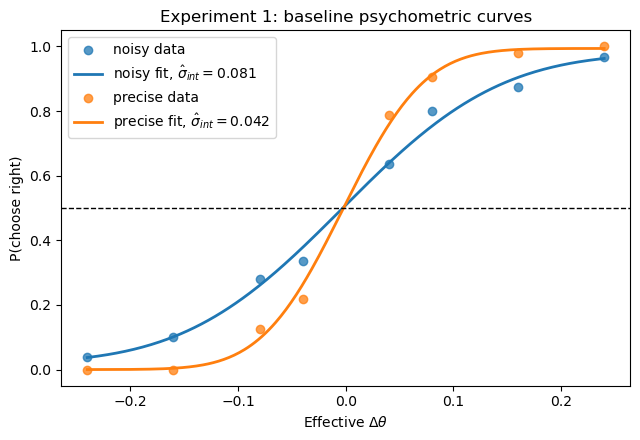

In [20]:
baseline_summary = summarize_choices(
    baseline,
    group_cols=("subject_id", "context", "sigma_ext", "effective_delta"),
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for subject_id, group in baseline_summary.groupby("subject_id"):
    ax.scatter(
        group["effective_delta"],
        group["p_choose_right"],
        alpha=0.75,
        label=f"{subject_id} data",
    )
    fit = baseline_fits[baseline_fits["subject_id"] == subject_id].iloc[0].to_dict()
    x_grid = np.linspace(
        group["effective_delta"].min(),
        group["effective_delta"].max(),
        300,
    )
    ax.plot(
        x_grid,
        gaussian_psychometric(
            x_grid,
            bias=fit["bias"],
            sigma_stimulus=fit["sigma_stimulus"],
            lapse_low=fit["lapse_low"],
            lapse_high=fit["lapse_high"],
            rho=fit.get("rho", 0.0),
        ),
        linewidth=2,
        label=rf"{subject_id} fit, $\hat\sigma_{{int}}={fit['sigma_stimulus']:.3f}$",
    )

ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title("Experiment 1: baseline psychometric curves")
ax.set_xlabel(r"Effective $\Delta\theta$")
ax.set_ylabel("P(choose right)")
ax.legend()
fig.tight_layout()


## Experiment 2: Compute Subject-Specific External Noise

Now choose a target total per-stimulus noise level. Each subject receives a different external-noise standard deviation so that:

` sigma_internal^2 + sigma_ext^2 = sigma_target^2 `

If `sigma_target < sigma_internal`, that target is infeasible for that subject because adding noise cannot reduce total uncertainty.

In [21]:
estimated_subjects = baseline_fits.rename(
    columns={"sigma_stimulus": "sigma_internal"}
)[["subject_id", "sigma_internal"]]

SIGMA_TARGETS = (0.12,)
calibration = make_noise_calibration_table(estimated_subjects, SIGMA_TARGETS)
calibration


,subject_id,sigma_internal,sigma_target,sigma_ext,is_feasible
0,noisy,0.081416,0.12,0.088156,True
1,precise,0.042096,0.12,0.112374,True


## Matched-Noise Demonstration

Finally, simulate the second task using the calculated external noise. If the calibration worked, the recovered psychometric curves should overlap across subjects at the same `sigma_target`, even though their baseline thresholds differed.

In [22]:
matched = simulate_matched_noise_observers(
    subjects=estimated_subjects,
    sigma_targets=SIGMA_TARGETS,
    theta0=THETA0,
    delta_thetas=DELTA_THETAS,
    n_repeats=N_REPEATS,
    contexts=CONTEXTS,
    rng=21,
)

matched_fits = fit_all_gaussian_psychometrics(
    matched,
    group_cols=("subject_id", "context", "sigma_target"),
)
matched_fits[["subject_id", "sigma_target", "sigma_stimulus", "threshold_75", "success"]]


,subject_id,sigma_target,sigma_stimulus,threshold_75,success
0,noisy,0.12,0.111921,0.101344,True
1,precise,0.12,0.121057,0.114696,True


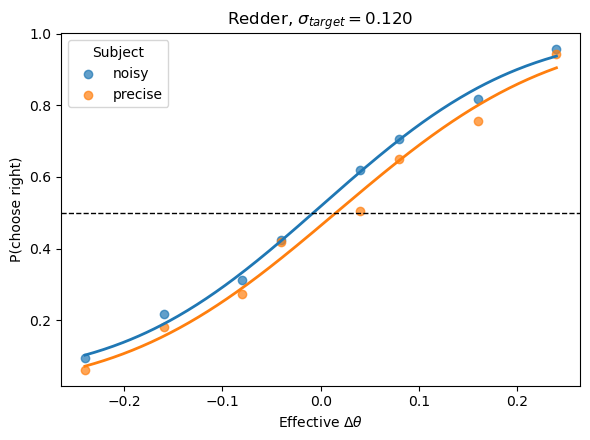

In [23]:
plot_matched_noise_psychometrics(matched, matched_fits, context="redder");
